In [257]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [258]:
df = pd.read_csv("datasets/Diamonds Prices2022.csv")

In [259]:
# Shape

print(f"Rows: {df.shape[0]}\nColumns: {df.shape[1]}")

Rows: 53943
Columns: 11


In [260]:
df.columns

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='object')

In [261]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [262]:
# Null values per feature

df.isnull().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [263]:
# Dataset overview

df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000
mean,26972.000000,0.797935,61.749322,57.457251,3932.734294,5.731158,5.734526,3.538730
std,15572.147122,0.473999,1.432626,2.234549,3989.338447,1.121730,1.142103,0.705679
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13486.500000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26972.000000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40457.500000,1.040000,62.500000,59.000000,5324.000000,6.540000,6.540000,4.040000
max,53943.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [264]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53943 entries, 0 to 53942
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53943 non-null  int64  
 1   carat       53943 non-null  float64
 2   cut         53943 non-null  object 
 3   color       53943 non-null  object 
 4   clarity     53943 non-null  object 
 5   depth       53943 non-null  float64
 6   table       53943 non-null  float64
 7   price       53943 non-null  int64  
 8   x           53943 non-null  float64
 9   y           53943 non-null  float64
 10  z           53943 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [265]:
# Duplicate rows

df.duplicated().sum()

0

## Section I: Preprocessing

In [266]:
# Drop useless columns (i.e. Unnamed: 0)

df.drop('Unnamed: 0', axis=1, inplace=True)

In [267]:
# Drop impossible diamond dimensions

df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]

In [268]:
# Drop price and move it to the end

price_col = df['price'].copy()
df.drop('price', axis=1, inplace=True)
df = pd.concat([df, price_col], axis=1)

df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335


In [269]:
# Numerical copy of the dataset

df_numerical = df.select_dtypes(include="number").copy()

## Section II: EDA

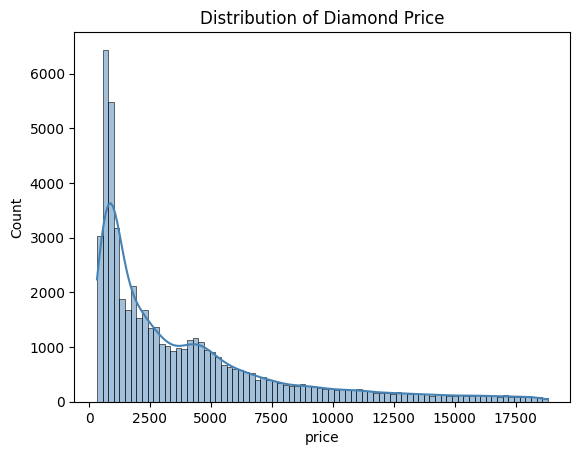

In [270]:
# Distribution of 'price'

plt.title("Distribution of Diamond Price")
sns.histplot(data=df['price'], kde=True, color='steelblue') # Make sure to use histplots for this
plt.show()

**Observation: The diamond prices are exremely right skewed**

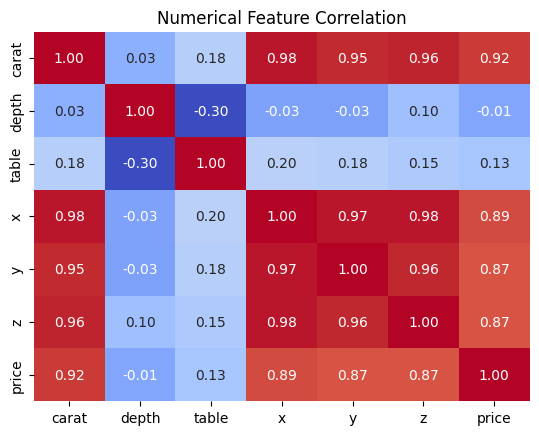

In [271]:
_corr = df_numerical.corr()
plt.title("Numerical Feature Correlation")
sns.heatmap(data=_corr, fmt='.2f', annot=True, cmap='coolwarm', cbar=False)
plt.show()

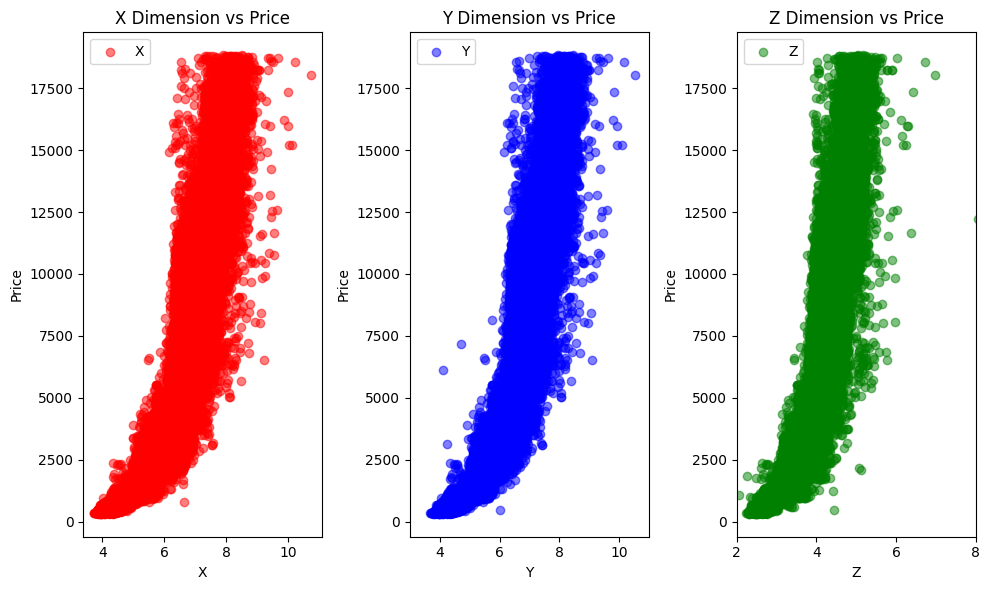

In [272]:
# Plot dimensions vs Price

colors = ['red', 'blue', 'green']
fig, ax = plt.subplots(1, 3, figsize=(10, 6))

ax[0].scatter(df['x'].values, df['price'].values, alpha=0.5, color=colors[0], label='X')
ax[0].set_title("X Dimension vs Price")
ax[0].set_xlabel("X")
ax[0].set_ylabel("Price")
ax[0].legend()

ax[1].scatter(df['y'].values, df['price'].values, alpha=0.5, color=colors[1], label='Y')
ax[1].set_title("Y Dimension vs Price")
ax[1].set_xlabel("Y")
ax[1].set_ylabel("Price")
ax[1].legend()
ax[1].set_xlim(3, 11)

ax[2].scatter(df['z'].values, df['price'].values, alpha=0.5, color=colors[2], label='Z')
ax[2].set_title("Z Dimension vs Price")
ax[2].set_xlabel("Z")
ax[2].set_ylabel("Price")
ax[2].legend()
ax[2].set_xlim(2, 8)  

plt.tight_layout()
plt.show()

**Price highly depends on dimensions, and it seems all the dimensions are highly colinear**

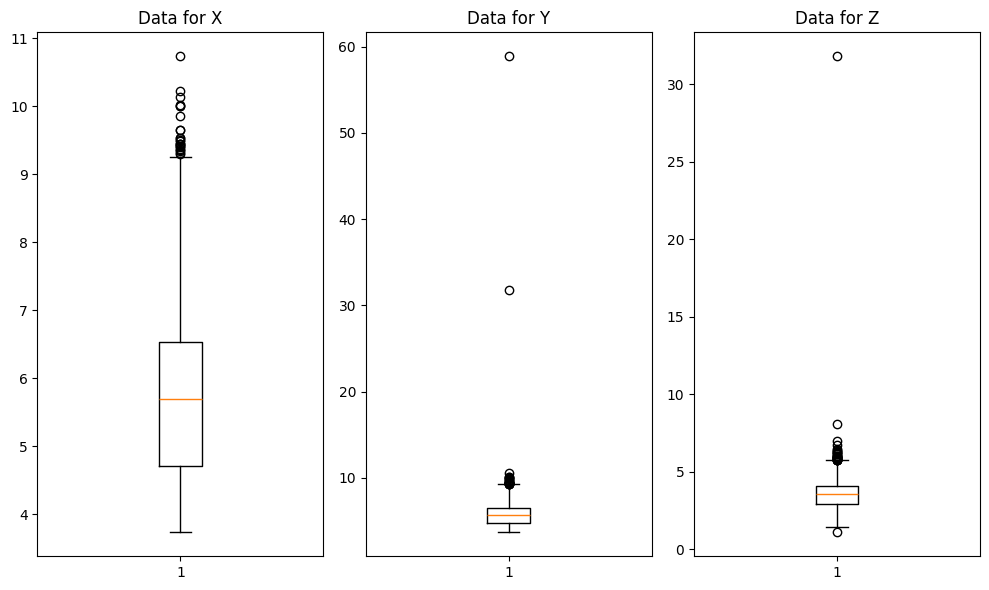

In [273]:
# Check to see outliers in X, Y, and Z

fig, ax = plt.subplots(1, 3, figsize=(10, 6))

ax[0].boxplot(df['x'].values)
ax[0].set_title("Data for X")

ax[1].boxplot(df['y'].values)
ax[1].set_title("Data for Y")

ax[2].boxplot(df['z'].values)
ax[2].set_title("Data for Z")

plt.tight_layout()
plt.show()

**The y and z dimensions had some huge outliers which needed to be removed**

In [274]:
# Remove the rows with outliers

def rm_outliers(col: str):
    q3 = np.quantile(df[col], 0.75)
    q1 = np.quantile(df[col], 0.25)
    iqr = q3 - q1

    ub = q3 + 1.5 * iqr
    lb = q1 - 1.5 * iqr

    return ~((df[col] > ub) | (df[col] < lb))

# Remove high/low outliers for all numerical columns 

for i in df_numerical.columns:
    df = df[rm_outliers(i)]

df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335
5,0.24,Very Good,J,VVS2,62.8,57.0,3.94,3.96,2.48,336


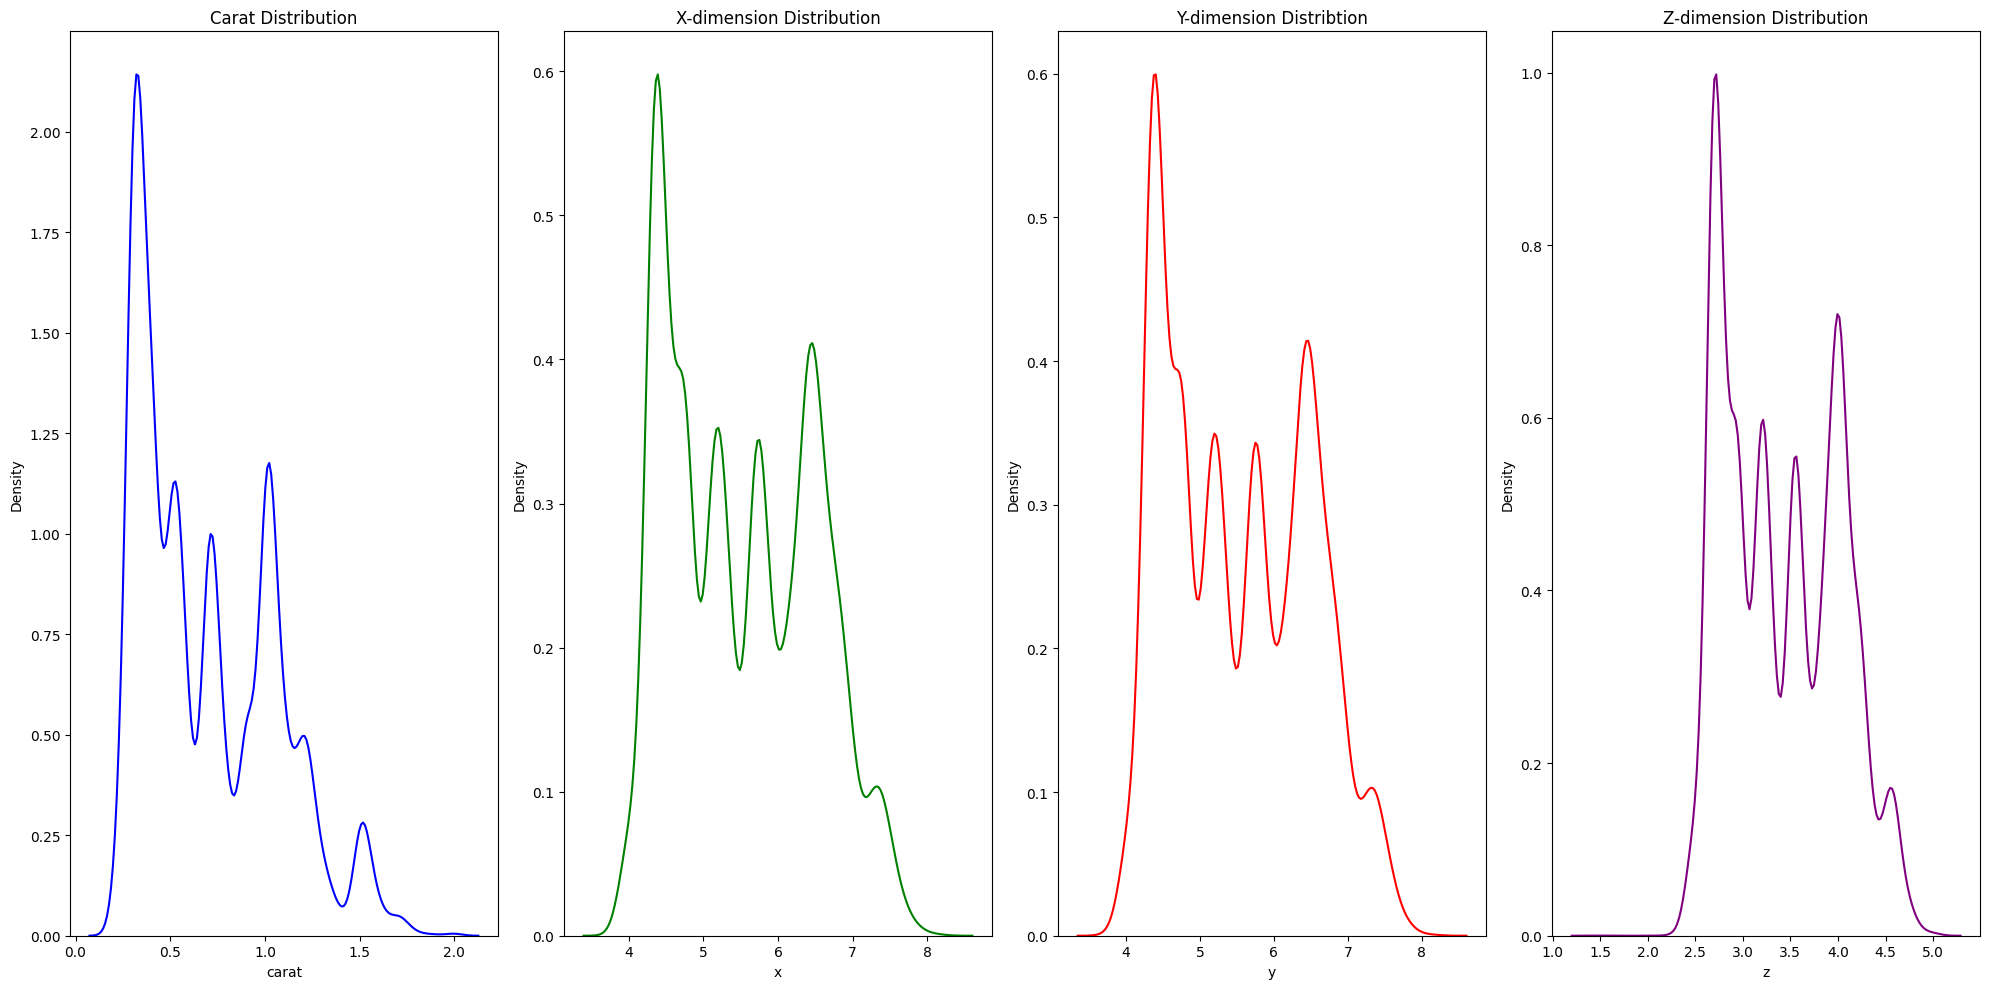

In [275]:
# See the distributions of carat, x, y, and z

cols = ['carat', 'x', 'y', 'z']
colors = ['blue', 'green', 'red', 'purple']
titles = ['Carat Distribution', 'X-dimension Distribution', 'Y-dimension Distribtion', 'Z-dimension Distribution']

fig, ax = plt.subplots(1, 4, figsize=(20, 10))

for idx, col in enumerate(cols):
    sns.kdeplot(data=df, x=col, color=colors[idx], ax=ax[idx], label=col)
    ax[idx].set_title(titles[idx])

plt.tight_layout()
plt.show()

**Confirmed Colinearity - therefore, we must remove x, y, and z for linear regression models**

## Section III: Model Application

In [276]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [277]:
# Encode the dataset based on column

from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[
    ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'],
    ['D', 'E', 'F', 'G', 'H', 'I', 'J'],
    ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
])

cols = ['cut', 'color', 'clarity']
df[cols] = oe.fit_transform(df[cols])


df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,4.0,1.0,1.0,61.5,55.0,3.95,3.98,2.43,326
1,0.21,3.0,1.0,2.0,59.8,61.0,3.89,3.84,2.31,326
3,0.29,3.0,5.0,3.0,62.4,58.0,4.20,4.23,2.63,334
4,0.31,1.0,6.0,1.0,63.3,58.0,4.34,4.35,2.75,335
5,0.24,2.0,6.0,5.0,62.8,57.0,3.94,3.96,2.48,336


In [278]:
# Make a new dataframe copy with the colinear columns removed

df_linear = df.drop(columns=['x', 'y', 'z'], axis=1).copy()

In [279]:
# Split the dataset into X and y

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_lin = df_linear.iloc[:, :-1].values
y_lin = df_linear.iloc[:, -1].values

In [280]:
# Split the data into training and testing 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_lin_train, X_lin_test, y_lin_train, y_lin_test = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)

In [281]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

X_lin_train = ss.fit_transform(X_lin_train)
X_lin_test = ss.transform(X_lin_test)

In [282]:
# Log derivation for skew minimization

y_train_log = np.log(y_train)
y_lin_train_log = np.log(y_lin_train)

In [283]:
# Apply a non-boosted regression tree

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

non_boost = DecisionTreeRegressor()
non_boost.fit(X_train, y_train_log)

y_pred_non_boost = np.exp(non_boost.predict(X_test))

non_boost_rmse = math.sqrt(mean_squared_error(y_test, y_pred_non_boost))

In [284]:
# Implement custom gradient boosting method (non-extreme)

def gradient_boost(X, y, M, md, learning_rate):
    models = []
    F = None
    r = None
    for m in range(M+1):
        if m == 0:
            F = np.full(y.shape[0], np.mean(y))
            r = y - F
        else:
            model = DecisionTreeRegressor(max_depth=md)
            model.fit(X, r)

            step_dir = model.predict(X)
            F = F + learning_rate * step_dir
            r = y - F

            models.append(model)
    return models

In [285]:
import time
start = time.perf_counter()

M = 500
learning_rate = 0.1
max_depth = 3

models = gradient_boost(X_train, y_train_log, M, max_depth, learning_rate)

end = time.perf_counter()

F = np.full(y_test.shape[0], y_train_log.mean())  
for model in models:
    f = model.predict(X_test)
    F = F + learning_rate * f

F = np.exp(F) 
post_boost_rmse = math.sqrt(mean_squared_error(y_test, F))

print(f"Model computation time: {end - start:.2f} seconds")

Model computation time: 23.04 seconds


In [286]:
# Fit and Predict on XGBoost Regressor

import xgboost as xgb

start = time.perf_counter()

x = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

x.fit(X_train, y_train_log)
y_pred_post_xgb = np.exp(x.predict(X_test))

end = time.perf_counter()

post_xgb_rmse = math.sqrt(mean_squared_error(y_test, y_pred_post_xgb))

print(f"Computation time: {end - start:.2f} seconds")

Computation time: 2.11 seconds


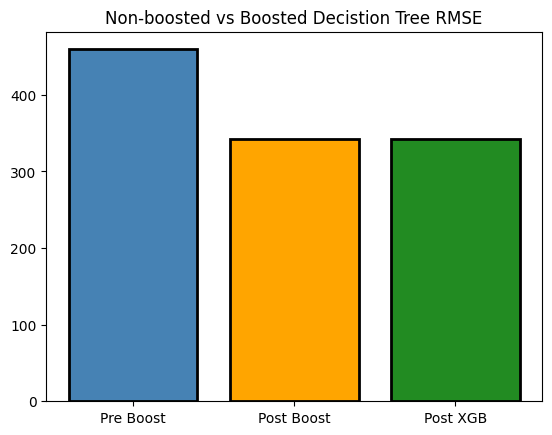

In [287]:
# Plot the difference in RMSE b/w a non-boosted and boosted model

labels = ['Pre Boost', 'Post Boost', 'Post XGB']
values = [non_boost_rmse, post_boost_rmse, post_xgb_rmse]

plt.bar(labels, values, color=['steelblue', 'orange', 'forestgreen'], edgecolor='black', linewidth=2)
plt.title("Non-boosted vs Boosted Decistion Tree RMSE")
plt.show()

**Question: Is a linear regressor better?**

In [288]:
from sklearn.linear_model import RidgeCV

rr = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])
rr.fit(X_lin_train, y_lin_train)

y_pred_rr = rr.predict(X_lin_test)

rr_rmse = math.sqrt(mean_squared_error(y_lin_test, y_pred_rr))

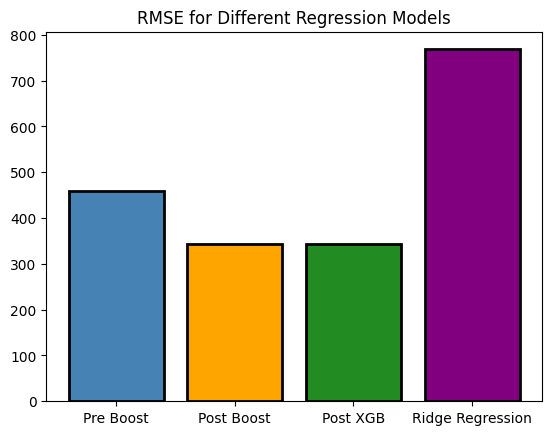

In [289]:
# Replot with linear regressor RMSE

labels.append('Ridge Regression')
values.append(rr_rmse)

plt.bar(labels, values, color=['steelblue', 'orange', 'forestgreen', 'purple'], edgecolor='black', linewidth=2)
plt.title("RMSE for Different Regression Models")
plt.show()

## Section IV: Cross Validation

In [290]:
# Find the best hyperparameters for the XGBoosted model

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

xgbr = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

param_dist = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': range(3, 11),
    'n_estimators': [100, 200, 300, 500, 700],
    'gamma': np.arange(0, 1, 0.1),
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

rand_search = RandomizedSearchCV(xgbr, param_distributions=param_dist, cv=5, 
    n_iter=50, scoring='neg_root_mean_squared_error', random_state=42, n_jobs=6
)
rand_search.fit(X_train, y_train)

opt_params_1 = rand_search.best_params_
opt_xgb_1 = rand_search.best_estimator_

y_pred_opt_xgb_1 = opt_xgb_1.predict(X_test)

In [292]:
# Re-apply GridSearch on the found parameters

print(f"Optimal Params from RandomizedSearch: {opt_params_1}")

# ~KEY~
# learning_rate = +-0.05 in either direction
# max_depth = +-1 in either direction
# n_estimators = +-50 in either direction
# gamma = +-0.05 in either direction

best_lr = opt_params_1['learning_rate']
best_depth = opt_params_1['max_depth']
best_n = opt_params_1['n_estimators']
best_gamma = opt_params_1['gamma']

param_grid = {
    'learning_rate': [
        max(0.01, best_lr - 0.05),
        best_lr,
        best_lr + 0.05
    ],
    'max_depth': [
        max(1, best_depth - 1),
        best_depth,
        best_depth + 1
    ],
    'n_estimators': [
        max(50, best_n - 50),
        best_n,
        best_n + 50
    ],
    'gamma': [
        max(0, best_gamma - 0.05),
        best_gamma,
        best_gamma + 0.05
    ]
}

print(f"Grid parameters: {param_grid}")

grid_search = GridSearchCV(
    xgbr,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=6
)

grid_search.fit(X_train, y_train)

opt_xgb_2 = grid_search.best_estimator_

y_pred_opt_xgb_2 = opt_xgb_2.predict(X_test)

print(f"Optimal Params 2: {grid_search.best_params_}")

Optimal Params from RandomizedSearch: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 0.7000000000000001, 'colsample_bytree': 0.9}
Grid parameters: {'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [8, 9, 10], 'n_estimators': [250, 300, 350], 'gamma': [0.65, 0.7000000000000001, 0.7500000000000001]}
Optimal Params 2: {'gamma': 0.65, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 250}


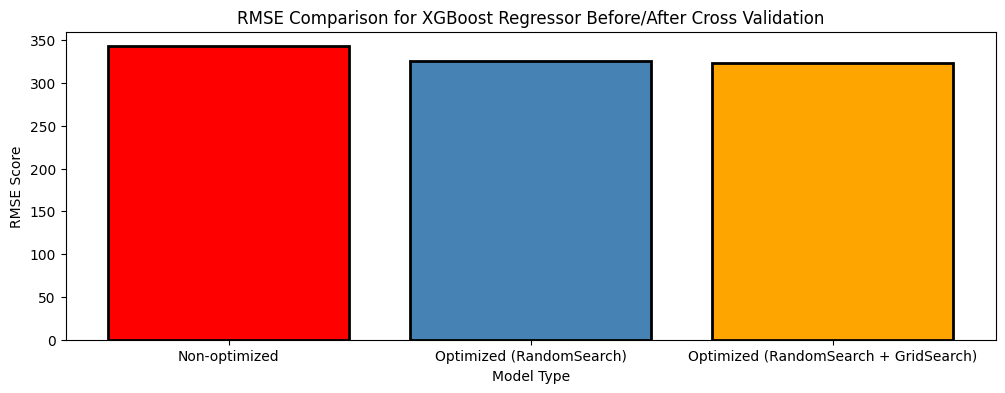

In [ ]:
from sklearn.metrics import root_mean_squared_error as rmse

non_opt_rmse = round(rmse(y_test, y_pred_post_xgb), 3)
opt_rmse_1 = round(rmse(y_test, y_pred_opt_xgb_1), 3)
opt_rmse_2 = round(rmse(y_test, y_pred_opt_xgb_2), 3)

colors = ['red', 'steelblue', 'orange']

plt.figure(figsize=(12, 4))
plt.bar(['Non-optimized', 'Optimized (RandomSearch)', 'Optimized (RandomSearch + GridSearch)'], 
    [non_opt_rmse, opt_rmse_1, opt_rmse_2], color=colors, edgecolor='black', linewidth=2)

plt.title('RMSE Comparison for XGBoost Regressor Before/After Cross Validation')
plt.xlabel('Model Type')
plt.ylabel('RMSE Score')
plt.show()

In [303]:
# Dump the model and encoder into joblib

import joblib

joblib.dump(opt_xgb_2, "diamond_prediction_model.pkl")
joblib.dump(oe, "diamond_features_ordinal_encoder")

['diamond_features_ordinal_encoder']

In [ ]:
# Load it for confirmation

model = joblib.load("diamond_prediction_model.pkl")
model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
